# GPU Fundamentals for LLM Inference

Before we can optimise LLM inference, we need to understand **why GPUs are fast** and
**what makes them slow**. This notebook covers the core principles:

1. CPU vs GPU — why GPUs dominate deep learning
2. Memory hierarchy — the real bottleneck
3. Host ↔ device transfers — the silent killer
4. Batching — why throughput ≠ latency
5. Arithmetic intensity — compute-bound vs memory-bound
6. Practical rules for keeping inference fast

## 1. CPU vs GPU — different tools for different jobs

| | CPU | GPU |
|---|---|---|
| Cores | 8–64 (complex, fast) | 1000–16000 (simple, parallel) |
| Clock speed | ~5 GHz | ~2 GHz |
| Optimised for | Sequential logic, branching | Bulk arithmetic on arrays |
| Memory | 32–512 GB (DDR5, ~50 GB/s) | 24–80 GB (HBM, ~2 TB/s) |

A CPU core is a Swiss Army knife — great at one complex task.
A GPU is a factory of thousands of workers — each does simple math, but together
they multiply millions of numbers per clock cycle.

**LLM inference is dominated by matrix multiplications** (attention projections, MLPs).
A single forward pass through Qwen3.5-2B involves multiplying matrices with billions of
elements. This maps perfectly to GPU parallelism.

```
CPU:  process 1 row of the matrix at a time, very fast per row
GPU:  process ALL rows simultaneously, slower per row but massively parallel

Matrix [1000, 2048] × [2048, 6144]:
  CPU: ~1000 sequential steps (one row at a time)
  GPU: ~1 step (all rows in parallel)
```

In [5]:
import time
import torch
import numpy as np

# Check what devices are available
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon (MPS)"
else:
    device = torch.device("cpu")
    device_name = "CPU only"

print(f"GPU device: {device_name}")
print(f"CPU cores: {torch.get_num_threads()}")

GPU device: Apple Silicon (MPS)
CPU cores: 8


In [6]:
# CPU vs GPU: matrix multiplication speed
sizes = [512, 1024, 2048, 4096]
print(f"{'Matrix size':<15} {'CPU (ms)':<12} {'GPU (ms)':<12} {'Speedup':<10}")
print("-" * 49)

for n in sizes:
    a_cpu = torch.randn(n, n)
    b_cpu = torch.randn(n, n)
    
    # CPU timing
    start = time.perf_counter()
    for _ in range(5):
        _ = a_cpu @ b_cpu
    cpu_time = (time.perf_counter() - start) / 5 * 1000
    
    # GPU timing
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)
    # Warmup
    for _ in range(3):
        _ = a_gpu @ b_gpu
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(5):
        _ = a_gpu @ b_gpu
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    gpu_time = (time.perf_counter() - start) / 5 * 1000
    
    speedup = cpu_time / gpu_time if gpu_time > 0 else 0
    print(f"{n}x{n:<10} {cpu_time:<12.2f} {gpu_time:<12.2f} {speedup:<10.1f}x")

Matrix size     CPU (ms)     GPU (ms)     Speedup   
-------------------------------------------------
512x512        0.24         0.38         0.6       x
1024x1024       1.31         1.08         1.2       x
2048x2048       7.66         3.25         2.4       x
4096x4096       59.65        25.08        2.4       x


## 2. Memory hierarchy — the real bottleneck

Most people think GPUs are fast because of raw compute. But modern GPUs can do math
**faster than they can feed data to the compute cores**. The bottleneck is memory.

```
┌─────────────────────────────────────────────────────────────┐
│  GPU Memory Hierarchy                                       │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  Registers        ← fastest (per-thread, ~TB/s)            │
│       ↕                                                     │
│  Shared Memory    ← fast (per-block, ~19 TB/s on H100)     │
│       ↕                                                     │
│  L2 Cache         ← moderate (shared, ~12 TB/s)            │
│       ↕                                                     │
│  HBM (Global)     ← slow (3.35 TB/s on H100, 80 GB)       │
│       ↕                                                     │
│  CPU RAM (Host)   ← very slow (~50 GB/s, via PCIe/NVLink)  │
│       ↕                                                     │
│  Disk/Network     ← glacial                                │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

**Key insight**: Every time data moves down this hierarchy, it gets ~10–100x slower.
Optimisation is largely about keeping data as close to the compute units as possible.

For LLMs:
- **Model weights** live in HBM (have to — they're too large for caches)
- **KV cache** lives in HBM (grows with sequence length)
- **Activations** ideally stay in shared memory during a kernel
- **FlashAttention** works by never materialising the full attention matrix in HBM

## 3. Host ↔ Device transfers — the silent killer

Moving data between CPU (host) and GPU (device) goes over PCIe or NVLink:
- **PCIe 4.0 x16**: ~25 GB/s
- **PCIe 5.0 x16**: ~50 GB/s  
- **NVLink (H100)**: ~900 GB/s (GPU ↔ GPU only)

Compare to GPU HBM bandwidth of 2–3 TB/s. A single PCIe transfer can stall the
entire pipeline.

**Rule**: Move data to GPU once, do ALL computation there, move results back once.
Every `.cpu()` or `.to(device)` in a loop is a red flag.

In [7]:
# Measure transfer overhead
sizes_mb = [1, 10, 50, 100]

print(f"{'Size (MB)':<12} {'CPU→GPU (ms)':<15} {'GPU→CPU (ms)':<15} {'Bandwidth (GB/s)':<18}")
print("-" * 60)

for mb in sizes_mb:
    numel = mb * 1024 * 1024 // 4  # float32 = 4 bytes
    tensor_cpu = torch.randn(numel)
    
    # CPU → GPU
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    start = time.perf_counter()
    tensor_gpu = tensor_cpu.to(device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    to_gpu_ms = (time.perf_counter() - start) * 1000
    
    # GPU → CPU
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    start = time.perf_counter()
    tensor_back = tensor_gpu.cpu()
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    to_cpu_ms = (time.perf_counter() - start) * 1000
    
    bandwidth = mb / 1024 / (to_gpu_ms / 1000) if to_gpu_ms > 0 else 0
    print(f"{mb:<12} {to_gpu_ms:<15.2f} {to_cpu_ms:<15.2f} {bandwidth:<18.2f}")

Size (MB)    CPU→GPU (ms)    GPU→CPU (ms)    Bandwidth (GB/s)  
------------------------------------------------------------
1            3.12            9.01            0.31              
10           20.34           1.03            0.48              
50           1.91            4.50            25.52             
100          4.97            16.94           19.65             


In [8]:
# The cost of transferring in a loop vs doing everything on-device
n = 1000
iterations = 100

# BAD: transfer every iteration
a_cpu = torch.randn(n, n)
b_cpu = torch.randn(n, n)

start = time.perf_counter()
for _ in range(iterations):
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)
    c_gpu = a_gpu @ b_gpu
    c_cpu = c_gpu.cpu()
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()
bad_time = (time.perf_counter() - start) * 1000

# GOOD: transfer once, compute on device
a_gpu = a_cpu.to(device)
b_gpu = b_cpu.to(device)
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()

start = time.perf_counter()
for _ in range(iterations):
    c_gpu = a_gpu @ b_gpu
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()
good_time = (time.perf_counter() - start) * 1000

print(f"With transfers each iteration:  {bad_time:.1f} ms ({iterations} matmuls)")
print(f"Without transfers (on-device):  {good_time:.1f} ms ({iterations} matmuls)")
print(f"\nOverhead from transfers: {bad_time / good_time:.1f}x slower")
print(f"\nLesson: .to(device) and .cpu() in a loop destroys performance.")
print(f"Move data once, compute everything on-device, read results once.")

With transfers each iteration:  115.0 ms (100 matmuls)
Without transfers (on-device):  40.2 ms (100 matmuls)

Overhead from transfers: 2.9x slower

Lesson: .to(device) and .cpu() in a loop destroys performance.
Move data once, compute everything on-device, read results once.


## 4. Batching — why throughput ≠ latency

A GPU has thousands of cores, but a single inference request (batch size 1) often
can't saturate them all — especially during decode where we're processing just 1 token.

**Batching** means processing multiple requests simultaneously:

```
Batch size 1:   [1, seq_len] × [2048, 6144]  → uses few GPU cores
Batch size 32:  [32, seq_len] × [2048, 6144]  → saturates the GPU
```

The weight matrix is loaded from memory **once** and reused across all items in the batch.
This is why batching improves **throughput** (tokens/sec total) dramatically,
while only slightly increasing **latency** (time per individual request).

| Batch size | Weight loads | Compute | Throughput | Latency |
|-----------|-------------|---------|-----------|--------|
| 1 | 1× | barely used | low | lowest |
| 8 | 1× (reused!) | moderate | ~8× | ~same |
| 32 | 1× (reused!) | saturated | ~32× | slightly higher |
| 128 | 1× (reused!) | maxed out | diminishing returns | noticeably higher |

In [9]:
# Batching: more work, ~same time (until we saturate)
hidden_size = 2048
output_size = 6144
weight = torch.randn(hidden_size, output_size, device=device)

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
results = []

print(f"{'Batch':<8} {'Time (ms)':<12} {'Throughput':<15} {'Latency/item':<15} {'GPU util':<10}")
print("-" * 60)

for bs in batch_sizes:
    x = torch.randn(bs, hidden_size, device=device)
    
    # Warmup
    for _ in range(5):
        _ = x @ weight
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    # Time it
    start = time.perf_counter()
    for _ in range(50):
        _ = x @ weight
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / 50 * 1000
    
    throughput = bs / elapsed * 1000  # items/sec
    latency_per = elapsed / bs
    results.append((bs, elapsed, throughput, latency_per))
    
    # Relative GPU utilization (normalized to max throughput)
    util = throughput / (batch_sizes[-1] / results[-1][1] * 1000) * 100 if len(results) > 0 else 0
    print(f"{bs:<8} {elapsed:<12.3f} {throughput:<15.0f} {latency_per:<15.4f} ")

Batch    Time (ms)    Throughput      Latency/item    GPU util  
------------------------------------------------------------
1        0.222        4495            0.2225          
2        0.235        8521            0.1174          
4        0.210        19041           0.0525          
8        0.241        33148           0.0302          
16       0.210        76305           0.0131          
32       0.246        130199          0.0077          
64       0.338        189207          0.0053          
128      0.621        206248          0.0048          


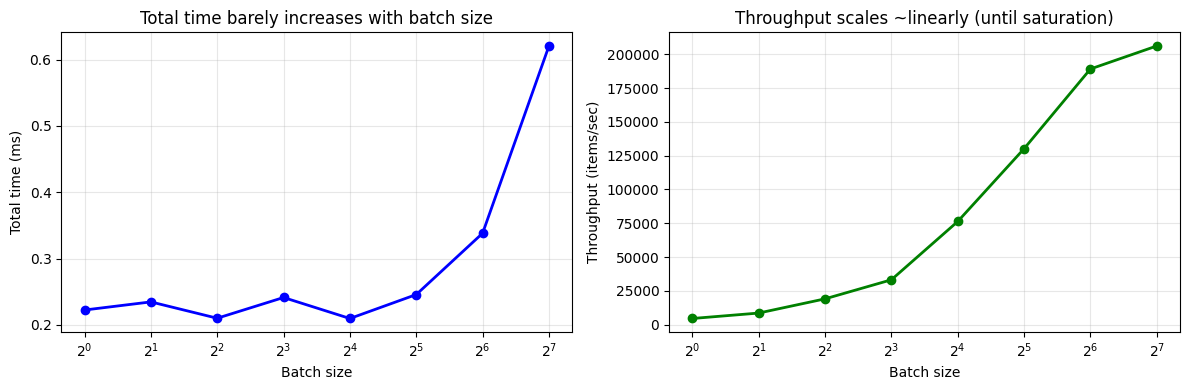


Batch 1 → 32: time went 1.1x, throughput went 29.0x
You get ~29x more work done for only ~1.1x the wall time.


In [10]:
import matplotlib.pyplot as plt

batch_list = [r[0] for r in results]
time_list = [r[1] for r in results]
throughput_list = [r[2] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(batch_list, time_list, 'o-', linewidth=2, color='blue')
ax1.set_xlabel("Batch size")
ax1.set_ylabel("Total time (ms)")
ax1.set_title("Total time barely increases with batch size")
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

ax2.plot(batch_list, throughput_list, 'o-', linewidth=2, color='green')
ax2.set_xlabel("Batch size")
ax2.set_ylabel("Throughput (items/sec)")
ax2.set_title("Throughput scales ~linearly (until saturation)")
ax2.set_xscale('log', base=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBatch 1 → 32: time went {results[5][1]/results[0][1]:.1f}x, throughput went {results[5][2]/results[0][2]:.1f}x")
print(f"You get ~{results[5][2]/results[0][2]:.0f}x more work done for only ~{results[5][1]/results[0][1]:.1f}x the wall time.")

## 5. Arithmetic intensity — are you compute-bound or memory-bound?

**Arithmetic intensity** = FLOPs performed / bytes loaded from memory.

This single number tells you what's limiting performance:

```
If arithmetic_intensity > GPU's compute:memory ratio → MEMORY-BOUND
   (waiting for data, compute cores are idle)
   
If arithmetic_intensity < GPU's compute:memory ratio → COMPUTE-BOUND
   (GPU is doing useful work, memory is keeping up)
```

For an H100:
- Compute: ~990 TFLOPS (fp16)
- Memory bandwidth: 3.35 TB/s
- **Breakeven: ~295 FLOPs per byte loaded**

### LLM inference phases:

| Phase | Arithmetic intensity | Bottleneck |
|-------|---------------------|------------|
| Prefill (large batch) | High — many tokens reuse same weights | Compute |
| Decode (batch=1) | Low — load full weight matrix for 1 token | **Memory** |
| Decode (batch=32) | Medium — 32 tokens reuse same weights | Balanced |

**This is why decode at batch=1 is so inefficient**: you load a 2048×6144 weight matrix
(25 MB in fp16) to multiply against a single 2048-dim vector. That's ~25M FLOPs but
~25 MB loaded = ~1 FLOP/byte. The GPU is starved for data.

In [11]:
# Demonstrate: matmul gets more efficient with larger batch (higher arithmetic intensity)
weight_size = (2048, 6144)
W = torch.randn(*weight_size, device=device, dtype=torch.float16)
weight_bytes = W.numel() * 2  # fp16 = 2 bytes

print(f"Weight matrix: {weight_size[0]}×{weight_size[1]} = {weight_bytes/1e6:.1f} MB (fp16)")
print(f"")
print(f"{'Batch':<8} {'FLOPs':<15} {'Bytes loaded':<15} {'Arith. intensity':<20} {'Regime':<15}")
print("-" * 73)

for bs in [1, 8, 32, 128, 512]:
    flops = 2 * bs * weight_size[0] * weight_size[1]  # matmul FLOPs = 2*M*N*K
    # Bytes loaded: weight matrix + input + output
    input_bytes = bs * weight_size[0] * 2
    output_bytes = bs * weight_size[1] * 2
    total_bytes = weight_bytes + input_bytes + output_bytes
    
    intensity = flops / total_bytes
    regime = "MEMORY-BOUND" if intensity < 100 else "COMPUTE-BOUND" if intensity > 200 else "BALANCED"
    
    print(f"{bs:<8} {flops/1e6:<15.1f}M {total_bytes/1e6:<15.1f}M {intensity:<20.1f} {regime:<15}")

print(f"\nNotice: the weight matrix ({weight_bytes/1e6:.1f} MB) is loaded once regardless of batch size.")
print(f"Larger batch = more FLOPs for the same memory load = higher efficiency.")

Weight matrix: 2048×6144 = 25.2 MB (fp16)

Batch    FLOPs           Bytes loaded    Arith. intensity     Regime         
-------------------------------------------------------------------------
1        25.2           M 25.2           M 1.0                  MEMORY-BOUND   
8        201.3          M 25.3           M 8.0                  MEMORY-BOUND   
32       805.3          M 25.7           M 31.3                 MEMORY-BOUND   
128      3221.2         M 27.3           M 118.2                BALANCED       
512      12884.9        M 33.6           M 384.0                COMPUTE-BOUND  

Notice: the weight matrix (25.2 MB) is loaded once regardless of batch size.
Larger batch = more FLOPs for the same memory load = higher efficiency.


## 6. Practical rules for fast inference

### Do:
- **Keep everything on-device** — move model and data to GPU once
- **Batch requests** — saturate the GPU's compute cores
- **Use fp16/bf16** — halves memory, doubles effective bandwidth, negligible quality loss
- **Fuse operations** — fewer kernel launches, less HBM round-trips (FlashAttention does this)
- **Use KV cache** — avoid recomputing attention over seen tokens
- **Right-size your model** — a smaller model at full utilization beats a larger model at 10% utilization

### Don't:
- **Transfer data in loops** — `.cpu()` or `.to(device)` inside generation loops
- **Use batch=1 for throughput** — you're paying for the full weight load for one vector
- **Materialise large intermediates** — the full `[seq, seq]` attention matrix doesn't need to live in HBM
- **Use float32 when fp16 suffices** — doubles memory pressure for no quality gain
- **Launch many small kernels** — each kernel launch has microseconds of overhead

### The optimisation landscape for LLM serving:

```
┌────────────────────────────────────────────────────────────────┐
│                    Where time goes                             │
├────────────────────────────────────────────────────────────────┤
│                                                                │
│  Prefill:    Attention matmuls   ──→ FlashAttention, TP        │
│              MLP matmuls         ──→ Quantization, TP          │
│                                                                │
│  Decode:     Weight loading      ──→ Quantize (INT4/INT8)      │
│              KV cache reading    ──→ GQA, KV quant, PagedAttn  │
│              Low GPU util        ──→ Batching, continuous batch │
│              Sequential tokens   ──→ Speculative decoding      │
│                                                                │
│  Transfer:   Host↔Device         ──→ Keep on device, overlap   │
│              Multi-GPU comm      ──→ NVLink, tensor parallel    │
│                                                                │
└────────────────────────────────────────────────────────────────┘
```

In [12]:
# Summary: dtype matters — fp16 vs fp32
n = 4096

for dtype, name in [(torch.float32, "fp32"), (torch.float16, "fp16")]:
    a = torch.randn(n, n, device=device, dtype=dtype)
    b = torch.randn(n, n, device=device, dtype=dtype)
    
    # Warmup
    for _ in range(5):
        _ = a @ b
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(20):
        _ = a @ b
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / 20 * 1000
    
    mem = a.numel() * a.element_size() * 2 / 1e6  # two matrices
    print(f"{name}: {elapsed:.2f} ms | Memory for inputs: {mem:.0f} MB")

print(f"\nfp16 uses half the memory AND can be faster (tensor cores on NVIDIA, AMX on Apple).")
print(f"This is why LLM serving almost always uses fp16/bf16 or quantized formats.")

fp32: 25.32 ms | Memory for inputs: 134 MB
fp16: 22.74 ms | Memory for inputs: 67 MB

fp16 uses half the memory AND can be faster (tensor cores on NVIDIA, AMX on Apple).
This is why LLM serving almost always uses fp16/bf16 or quantized formats.
